In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

%load_ext autoreload
%autoreload 2

## first: try to reproduce Baibhav's plots

In [ ]:
from astro import calc_relative_semimajoraxis
from astro import calc_e2

def calc_cos_theta_k_max(beta, uk):
    return (2 * beta - uk**2 - 1) / 2 / uk

def calc_angles_par(uk, theta_k, phi_k):
    cos_theta_k = jnp.cos(theta_k)
    sin_theta_k = jnp.sin(theta_k)

    cos_phi_k = jnp.cos(phi_k)
    sin_phi_k = jnp.sin(phi_k)

    uy = uk * cos_theta_k
    uz = uk * sin_theta_k * cos_phi_k

    cos_theta_lli = uy + 1
    cos_theta_lli /= jnp.sqrt(uz**2 + (uy + 1)**2)

    sin_theta_lli = jnp.sin(jnp.arccos(cos_theta_lli))

    cos_theta_s = sin_theta_k * cos_phi_k
    sin_theta_s = jnp.sin(jnp.arccos(cos_theta_s))

    sin_phi_s = cos_theta_k / jnp.sqrt(
        sin_theta_k**2 * sin_phi_k**2 + cos_theta_k**2
    )

    cos_theta_ls = (
        cos_theta_s * cos_theta_lli
        + sin_theta_s * sin_theta_lli * sin_phi_s
    )

    #cos_theta_ls_alt = uk * sin_theta_k * cos_phi_k
    #cos_theta_ls_alt /= jnp.sqrt(uz**2 * (uy + 1)**2)

    #cos_theta_ls_alt_b1 = jnp.sqrt(1 - cos_theta_lli**2) / uk
    #cos_theta_ls_alt_b2 = -jnp.sqrt(1 - cos_theta_lli**2) / uk


    return cos_theta_lli, sin_phi_s, cos_theta_ls #, cos_theta_ls_alt_b1, cos_theta_ls_alt_b2 

In [35]:
n = 1_000_000
cos_theta_k = jax.random.uniform(jax.random.key(1), (n,)) * 2 - 1
phi_k = jax.random.uniform(jax.random.key(2), (n,)) * 2 * jnp.pi

uk = 1.5
beta = 1.0

cos_theta_lli, sin_phi_s, cos_theta_ls = calc_angles_par(uk, cos_theta_k, phi_k) #cos_theta_ls_alt_b1, cos_theta_ls_alt_b2 = calc_angles_par(uk, cos_theta_k, phi_k)

In [36]:
_, _, cos_theta_ls_b2 = calc_angles_par(uk, cos_theta_k, phi_k, branch=-1)

In [37]:
cos_theta_ls.min(), cos_theta_ls.max()

(Array(-0.9999992, dtype=float64), Array(0.99999433, dtype=float64))

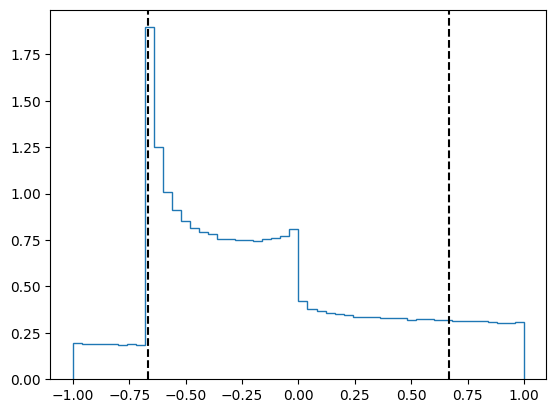

In [38]:
fig, ax = plt.subplots()
#ax.hist(cos_theta_ls, histtype='step', bins=50, density=True)
#ax.hist(cos_theta_ls_alt_b1, histtype='step', bins=50, density=True)
#ax.hist(cos_theta_ls_alt_b2, histtype='step', bins=50, density=True)
ax.hist(jnp.concatenate((cos_theta_ls, cos_theta_ls_b2)), histtype='step', bins=50, density=True);

ax.axvline(x=1/uk, linestyle='--', color='black')
ax.axvline(x=-1/uk, linestyle='--', color='black')

#ax.hist(cos_theta_ls_alt[], histtype='step', bins=50, density=True);
#ax.set_yscale('log');